# Course Overview

## Agenda

- Course overview
    - Topics and timelines
    - Deliverables overview
    - Project overview
- Data fundamentals
    - Image data
    - Audio data
- Lab
- Study guide

## About Me

::: {.columns}
::: {.column width="60%"}
**Background**

- **Adjunct Professor at Georgetown (since 2022)**
  - Deep Learning
  - Reinforcement Learning
  - Computer Vision & Generative Modeling

- **Industry Experience**: 
    - Data Scientist at Leidos
      - Applied ML/AI research in energy sector
    - Data Scientist at Axle Informatics
      - Computer vision in bioinformatics
  
:::
::: {.column width="40%"}
![](./images/ben.jpg)
:::

**Some Real-World CV Projects**

- Built **semantic segmentation models** (U-Net) to detect well locations from historical maps
- Developed **document digitization pipelines** using Transformers and Google DocAI
  

**Education & Interests**

- **MS in Data Science**, Georgetown University
- **BS in Petroleum Engineering**, West Virginia University
- **Interests**: Computer vision, deep learning, reinforcement learning, multimodal systems, agentic systems
:::

## Course Structure

**Deliverables:**

- **Weekly labs** (practice + skill-building)
- **Weekly quizzes** (in-class, lowest 3 dropped)
- **3 project check-ins** (milestones)
- **CV Spotlight presentation** (group)
- **Final presentation + repo**

**Details in Canvas**, refer there for due dates and rubrics.

## Weeks 1–5

**Week 01: Foundations of Image and Audio Data**

- How cameras/mics create tensors, sampling, quantization, PyTorch ecosystem
- *Project relevance:* Data loading, preprocessing pipelines

**Week 02: Classical Computer Vision**

- Filtering, edge detection, morphology, OpenCV pipelines
- *Project relevance:* Traditional preprocessing for hybrid approaches

**Week 03: Fourier Methods and Feature Engineering**

- Spectrograms, frequency-domain intuition, hand-crafted features
- *Project relevance:* Audio analysis, texture features

**Week 04: CNNs for Vision (Accelerated)**

- CNN fundamentals, modern architectures (ResNet, EfficientNet), transfer learning
- *Project relevance:* Backbone for most vision tasks

**Week 05: Object Detection I - Foundations**

- R-CNN family, ROI pooling, NMS (non-maximum suppression)
- *Project relevance:* Detecting objects in images/video

## Weeks 6–10

**Week 06: Object Detection II - Modern Detectors**

- Faster R-CNN, YOLO, feature pyramids for multi-scale detection
- *Project relevance:* Real-time detection, embedded systems

**Week 07: Image Segmentation**

- Semantic and instance segmentation (U-Net, Mask R-CNN)
- *Project relevance:* Pixel-level classification, medical imaging, scene parsing

**Week 08: Object Tracking**

- Tracking-by-detection, SORT/DeepSORT, temporal consistency
- *Project relevance:* Video analysis, surveillance, sports analytics

**Week 09: Generative Models**

- GANs and diffusion-based image generation
- *Project relevance:* Data augmentation, style transfer, synthetic data

**Week 10: Vision Transformers**

- Self-attention for vision, CNN vs Transformer comparisons
- *Project relevance:* State-of-the-art image classification, modern backbones

## Weeks 11–14

**Week 11: Multi-modal Vision Systems**

- Vision–language models (CLIP), shared embeddings, cross-modal learning
- *Project relevance:* Image captioning, VQA, text-to-image search

**Week 12: Data-Efficient Learning**

- Few-shot, zero-shot, and self-supervised learning strategies
- *Project relevance:* Working with limited labeled data, domain adaptation

**Week 13: Adversarial Robustness and Deepfakes**

- Adversarial examples, model vulnerabilities, deepfake detection
- *Project relevance:* Model security, media forensics, robust classifiers

**Week 14: Final Presentations**

- Student project presentations and course wrap-up

Most projects will combine 2–3 of these topics

- detection + tracking
- segmentation + generative
- multimodal + few-shot

## Tooling for This Course

**Core stack:**

- Python + Jupyter
- PyTorch (deep learning framework)
- torchvision / torchaudio (CV/audio utilities)
- matplotlib (visualization)
- openCV (image processing)

Recommended to create a new conda environment for this course.

**Hardware**

- Typical laptop should be sufficient for typical course work
    - might not be enough for all projects
- Access to GPU is beneficial
- Consider using [Google Colab](https://colab.research.google.com/) or other cloud-based options for more powerful hardware

Recommended to create a new conda environment for this course.

# Images and Audio as Tensors

## Where image data comes from

### How do cameras turn the world into data?

**Light enters the camera** → hits a sensor grid of **millions of photosensitive pixels**

**Each pixel:**

1. **Spatially samples** light from a tiny region of the scene
2. **Color filters** (e.g., Bayer pattern) separate R, G, B wavelengths
3. **Photodiode** converts photons to electrical charge
4. **ADC** (analog-to-digital converter) quantizes charge → integer value

**Result:** A 3D array `(H, W, C)` where:

- **H × W** = spatial sampling (resolution)
- **C** = color channels (typically 3 for RGB)
- Values = quantized light intensity (e.g., 0-255 for 8-bit)

Images are *sampled* and *quantized* representations of continuous light fields

## Where audio data comes from

### How do microphones turn sound into data?

**Sound waves (air pressure variations)** → hit a **diaphragm** → converted to electrical signal

**Each sample:**

1. **Temporally samples** air pressure at regular intervals (e.g., 16,000 times/second)
2. **Transducer** (condenser, dynamic, or MEMS) converts mechanical vibration → voltage
3. **ADC** (analog-to-digital converter) quantizes voltage → integer value
4. **Multi-channel:** Stereo/surround uses multiple microphones simultaneously

**Result:** A 1D or 2D array where:

- **1D:** `(samples,)` for mono audio
- **2D:** `(channels, samples)` for stereo/multi-channel
- Values = quantized air pressure (e.g., 16-bit PCM: -32768 to +32767)

Audio is a *temporal* signal sampled at regular intervals (unlike images which sample *spatial* regions)

## Everything is a Tensor

In modern CV/audio systems, **everything is a tensor** (multi-dimensional array).

**Image tensors:**

- `(H, W, C)`: height × width × channels (NumPy/PIL convention)
- `(C, H, W)`: channels × height × width (PyTorch convention)

**Audio tensors:**

- `(samples,)`: mono audio
- `(channels, samples)`: stereo audio

**Batch dimension:**

- Add leading `N`: `(N, C, H, W)` for images (PyTorch)

**Key survival skill:** "shape thinking"

## Demo: Load ONE Real Image

**We'll reuse this image throughout the lecture.**

Shape: (1299, 2309, 3)
Data type: uint8
Value range: [0, 255]


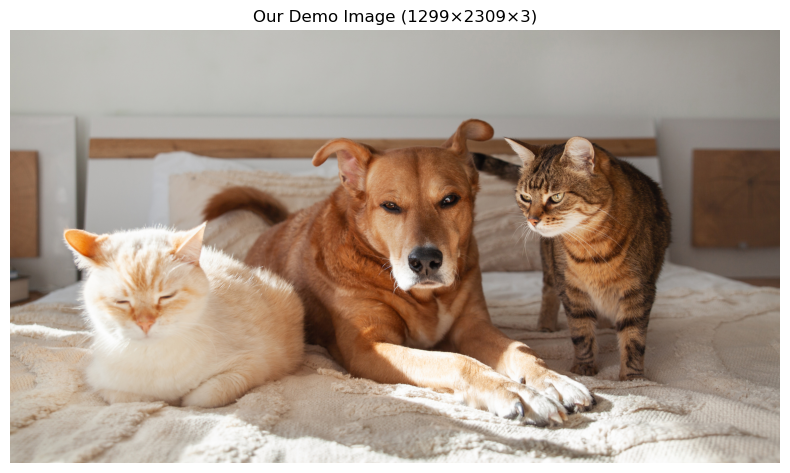

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Load the real image
img_pil = Image.open('./images/cats-dog.jpg')
img = np.array(img_pil)

print(f"Shape: {img.shape}")
print(f"Data type: {img.dtype}")
print(f"Value range: [{img.min()}, {img.max()}]")

# Display
fig, ax = plt.subplots(figsize=(8, 6))
ax.imshow(img)
ax.set_title(f"Our Demo Image ({img.shape[0]}×{img.shape[1]}×{img.shape[2]})")
ax.axis('off')
plt.tight_layout()
plt.show()

## What Does a Pixel Mean?

- A pixel is a **measurement**, not "truth"
    - The pixel value comes from a sensor (e.g., a camera or scanner). It can be noisy, distorted, or affected by lighting, not a perfect record of reality.
- RGB channels = 3 sensor measurements per location
- "Red" is **relative** to context and white balance

In [3]:
# Pick a few coordinates and print pixel values
coords = [(100, 100), (200, 300), (400, 150)]

print("Sample pixel values (RGB):")
for y, x in coords:
    r, g, b = img[y, x]
    print(f"  Position (row={y}, col={x}): R={r}, G={g}, B={b}")

Sample pixel values (RGB):
  Position (row=100, col=100): R=188, G=187, B=182
  Position (row=200, col=300): R=192, G=191, B=186
  Position (row=400, col=150): R=185, G=184, B=180


## Demo: NumPy ↔ PyTorch Shape Conventions

**This is where many early bugs come from.**

In [4]:
import torch

# NumPy format (HWC)
print(f"NumPy (HWC): {img.shape}")

# Convert to PyTorch format (CHW)
img_chw = np.transpose(img, (2, 0, 1))
print(f"PyTorch (CHW): {img_chw.shape}")

# Add batch dimension (NCHW)
img_batch = img_chw[np.newaxis, ...]
print(f"Batch (NCHW): {img_batch.shape}")

# Convert to PyTorch tensor
img_tensor = torch.from_numpy(img_chw).float() / 255.0
print(f"\nPyTorch tensor shape: {img_tensor.shape}")
print(f"PyTorch tensor dtype: {img_tensor.dtype}")
print(f"Value range: [{img_tensor.min():.3f}, {img_tensor.max():.3f}]")

NumPy (HWC): (1299, 2309, 3)
PyTorch (CHW): (3, 1299, 2309)
Batch (NCHW): (1, 3, 1299, 2309)

PyTorch tensor shape: torch.Size([3, 1299, 2309])
PyTorch tensor dtype: torch.float32
Value range: [0.000, 1.000]


## Beyond 3D: Higher-Dimensional Tensors

Computer vision often works with **more than 3 dimensions**:

**Video/time series:**

- `(T, C, H, W)`: time × channels × height × width

**Bioinformatics example:**

- `(T, C, D, H, W)`: time × channel (multi-stain) × depth × height × width
- [Bio Image reader and writer](https://bfio.readthedocs.io/en/latest/index.html)

**Multi-spectral / hyperspectral:**

- `(H, W, num_bands)` — 10+ channels instead of 3 (RGB)

**Key principle:** The **shape tells you the story**

## Audio as Tensors

Audio signals are **1D time-series** data:

- **Raw waveform**: `(num_samples,)`: amplitude values over time
- **Stereo**: `(2, num_samples)`: left and right channels
- **Sample rate**: samples per second (e.g., 16 kHz, 44.1 kHz)

**Key difference from images:**

- Images: **spatial** dimensions
- Audio: **temporal** dimension

**Today's demos:**

- Synthetic sine wave (always works)
- Real audio file: `hello.m4a`

=== Synthetic Audio ===
Shape: (3200,)
Sample rate: 16000 Hz
Duration: 0.2 seconds


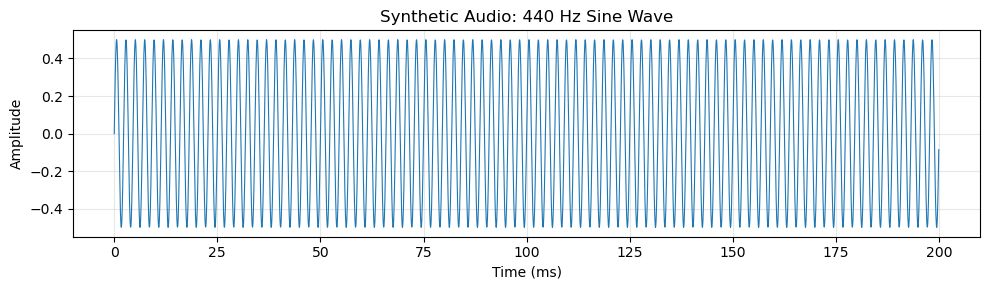

In [5]:
import IPython.display as ipd

# Demo 1: Generate a simple sine wave (440 Hz = A note)
sample_rate = 16000
duration = 0.2  # 200ms
t = np.linspace(0, duration, int(sample_rate * duration), endpoint=False)
frequency = 440.0
audio_synthetic = 0.5 * np.sin(2 * np.pi * frequency * t)

print("=== Synthetic Audio ===")
print(f"Shape: {audio_synthetic.shape}")
print(f"Sample rate: {sample_rate} Hz")
print(f"Duration: {duration} seconds")

# Plot waveform
fig, ax = plt.subplots(figsize=(10, 3))
time_ms = t * 1000
ax.plot(time_ms, audio_synthetic, linewidth=0.8)
ax.set_xlabel("Time (ms)")
ax.set_ylabel("Amplitude")
ax.set_title("Synthetic Audio: 440 Hz Sine Wave")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

ipd.Audio(audio_synthetic, rate=sample_rate)



=== Real Audio File ===
Shape: torch.Size([2, 41984])
Sample rate: 48000 Hz
Duration: 0.87 seconds


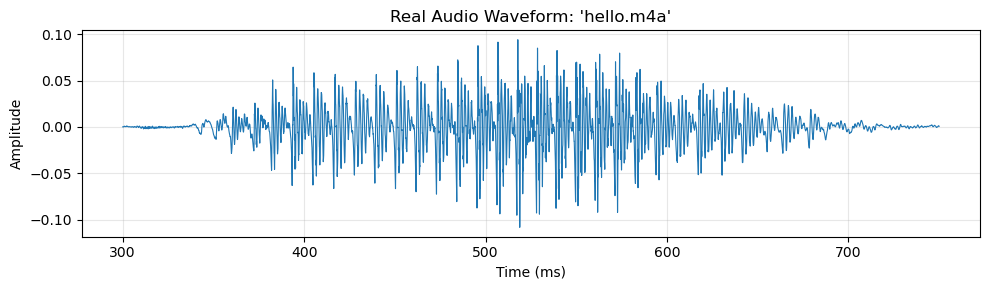

In [6]:
# Demo 2: Load real audio file
import torchaudio

audio_path = './images/hello.m4a'
audio, sr = torchaudio.load(audio_path)

print("\n=== Real Audio File ===")
print(f"Shape: {audio.shape}")
print(f"Sample rate: {sr} Hz")
print(f"Duration: {audio.shape[1] / sr:.2f} seconds")

# Convert to numpy for plotting
audio_np = audio.numpy()

start_time = 300 # ms
end_time = 750 # ms

# Time to sample indices
start_sample = int(start_time * sr / 1000)
end_sample = int(end_time * sr / 1000)

time_ms = np.arange(start_sample, end_sample) / sr * 1000

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(time_ms, audio_np[0, start_sample:end_sample], linewidth=0.8)
ax.set_xlabel("Time (ms)")
ax.set_ylabel("Amplitude")
ax.set_title(f"Real Audio Waveform: 'hello.m4a'")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()




In [7]:
# Play the audio inline (works in Jupyter and rendered HTML)
import IPython.display as ipd

print("Audio player:")
ipd.Audio(audio_np[0, start_sample:end_sample], rate=sr)

Audio player:


<!-- ## Why We Care: Models Don't "See", They Compute

- Neural networks consume **arrays of numbers**
- Representation choices matter:
  - Channel order
  - Value scale (0–255 vs 0–1)
  - Resolution

**Connection to upcoming CNN content:**
CNNs learn **spatial patterns** from these tensor representations. -->

# File Types & Conversions

**File formats are interfaces between tools** — and they're full of sharp edges.

**Main points:**

- **Lossy vs lossless** compression
- **Container vs codec** (especially for audio/video)
- **Bit depth** and **color space**
- **Metadata** can change behavior

## Images: JPEG vs PNG vs WebP (and the hidden gotchas)

**Common formats:**

- **JPEG**: lossy compression (good for photos)
  - Artifacts accumulate with repeated saves
  - Block artifacts visible at low quality
- **PNG**: lossless; supports alpha channel
  - Larger files for photos
  - Great for graphics, text, screenshots
- **WebP**: modern format (lossy or lossless)
  - Better compression than JPEG/PNG
  - Not universally supported (yet)

**Hidden gotchas:**

- **Bit depth**: 8-bit (0–255) is common, but 16-bit exists (HDR, medical imaging)
- **Color space**: usually **sRGB**; "looks different" bugs often come from color management
- **EXIF metadata**: orientation, camera settings, timestamps

**Key point:** Conversions can change **pixel values**, not just file size.

## Audio: WAV vs MP3 vs M4A (containers vs codecs)

**Common formats:**

- **WAV**: typically uncompressed PCM
  - Easy to read everywhere
  - Large files (1 MB per minute at CD quality)
- **MP3**: lossy codec (MPEG-1 Audio Layer 3)
  - Smaller files (~1 MB per 10 minutes)
  - Decoding required (but widely supported)
- **M4A**: usually a **container** holding AAC audio
  - AAC is the codec (also lossy)
  - Codec support varies by tool/library

**Key properties:**

- **Sample rate**: 16 kHz (speech), 44.1 kHz (CD), 48 kHz (video)
- **Channels**: mono (1) vs stereo (2)
- **Bit depth**: 16-bit (CD quality) vs 24-bit (pro audio)

**Why this matters:** Reading `.m4a` in Python often requires **FFmpeg** + `torchaudio` or similar.

## Conversions: Practical Recipes + Rules of Thumb

**General principles:**

1. **Prefer lossless during analysis** → compress later for sharing
   - Images: use **PNG** for experiments; JPEG for final figures
   - Audio: use **WAV/FLAC** for experiments; MP3/AAC for sharing

2. **Avoid repeated lossy re-encodes**
   - Each re-save degrades quality (especially JPEG)
   - Always keep the original

3. **When to use Python vs command-line tools:**
   - **Python** (PIL, OpenCV, torchaudio): good for scripting + batch processing
   - **FFmpeg** (command-line): powerful for audio/video conversions
   - **ImageMagick**: batch image conversions with many format options

**Example conversion (audio):**

```bash
# Convert M4A to WAV using FFmpeg (command-line)
ffmpeg -i hello.m4a -ar 16000 hello.wav
```

**Same conversion in Python:**

In [8]:
import torchaudio
audio, sr = torchaudio.load('./images/hello.m4a')

# Resample if needed
if sr != 16000:
    resampler = torchaudio.transforms.Resample(sr, 16000)
    audio = resampler(audio)
torchaudio.save('./images/hello.wav', audio, 16000)

# Coordinates & Channel Conventions

## Coordinate Conventions

**Image coordinate system:**

- Origin at **top-left**
- Indexing: `img[row, col]` = `img[y, x]`
- y increases **downward**

**Common mistake:**

- Plots often label x then y → mismatch risk
- Swapping x/y is an easy bug to introduce

## Demo: Annotate Coordinates on Real Image

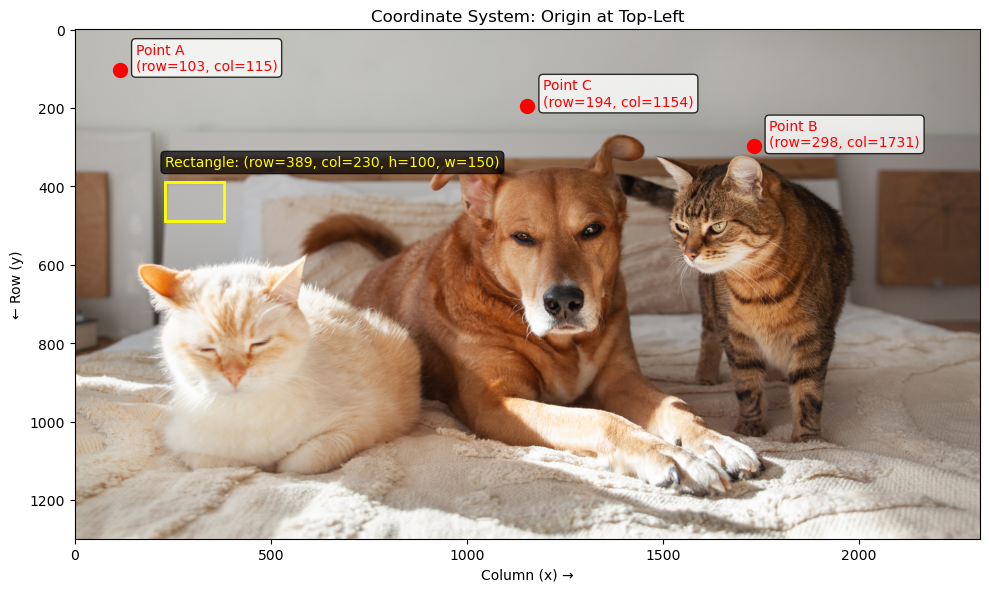


Image shape: (1299, 2309, 3)
Remember: img[row, col] but plot(col, row)!


In [9]:
from matplotlib.patches import Rectangle

# Draw points and boxes on the image
fig, ax = plt.subplots(figsize=(10, 7))
ax.imshow(img)

# Get image dimensions
H, W = img.shape[:2]

# Mark specific points (row, col) - scaled to image size
points = [
    (int(H * 0.08), int(W * 0.05), 'Point A'), # Top-left area
    (int(H * 0.23), int(W * 0.75), 'Point B'),   # Top-right area
    (int(H * 0.15), int(W * 0.5), 'Point C')  # Between A and B
]

for row, col, label in points:
    ax.plot(col, row, 'ro', markersize=10)  # Note: plot uses (x, y) = (col, row)
    ax.text(col + 40, row, f"{label}\n(row={row}, col={col})", 
            color='red', fontsize=10, bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# Draw a rectangle - scaled to image size
rect_col = int(W * 0.1)  # x position
rect_row = int(H * 0.3)  # y position
rect_w = 150   # width
rect_h = 100    # height

rect = Rectangle((rect_col, rect_row), rect_w, rect_h, 
                 linewidth=2, edgecolor='yellow', facecolor='none')
ax.add_patch(rect)
ax.text(rect_col, rect_row - 40, f"Rectangle: (row={rect_row}, col={rect_col}, h={rect_h}, w={rect_w})", 
        color='yellow', fontsize=10, bbox=dict(boxstyle='round', facecolor='black', alpha=0.7))

ax.set_title("Coordinate System: Origin at Top-Left")
ax.set_xlabel("Column (x) →")
ax.set_ylabel("← Row (y)")
plt.tight_layout()
plt.show()

print(f"\nImage shape: {img.shape}")
print("Remember: img[row, col] but plot(col, row)!")

## Channel Order: RGB vs BGR

**RGB** (most common):

- PIL, matplotlib, torchvision

**BGR** (OpenCV):

- Historical reasons from early OpenCV development

**Silent bug:**

- Colors look "off"
- Can go unnoticed in non-color-critical tasks
- Always check library documentation!

## Example: RGB ↔ BGR Bug

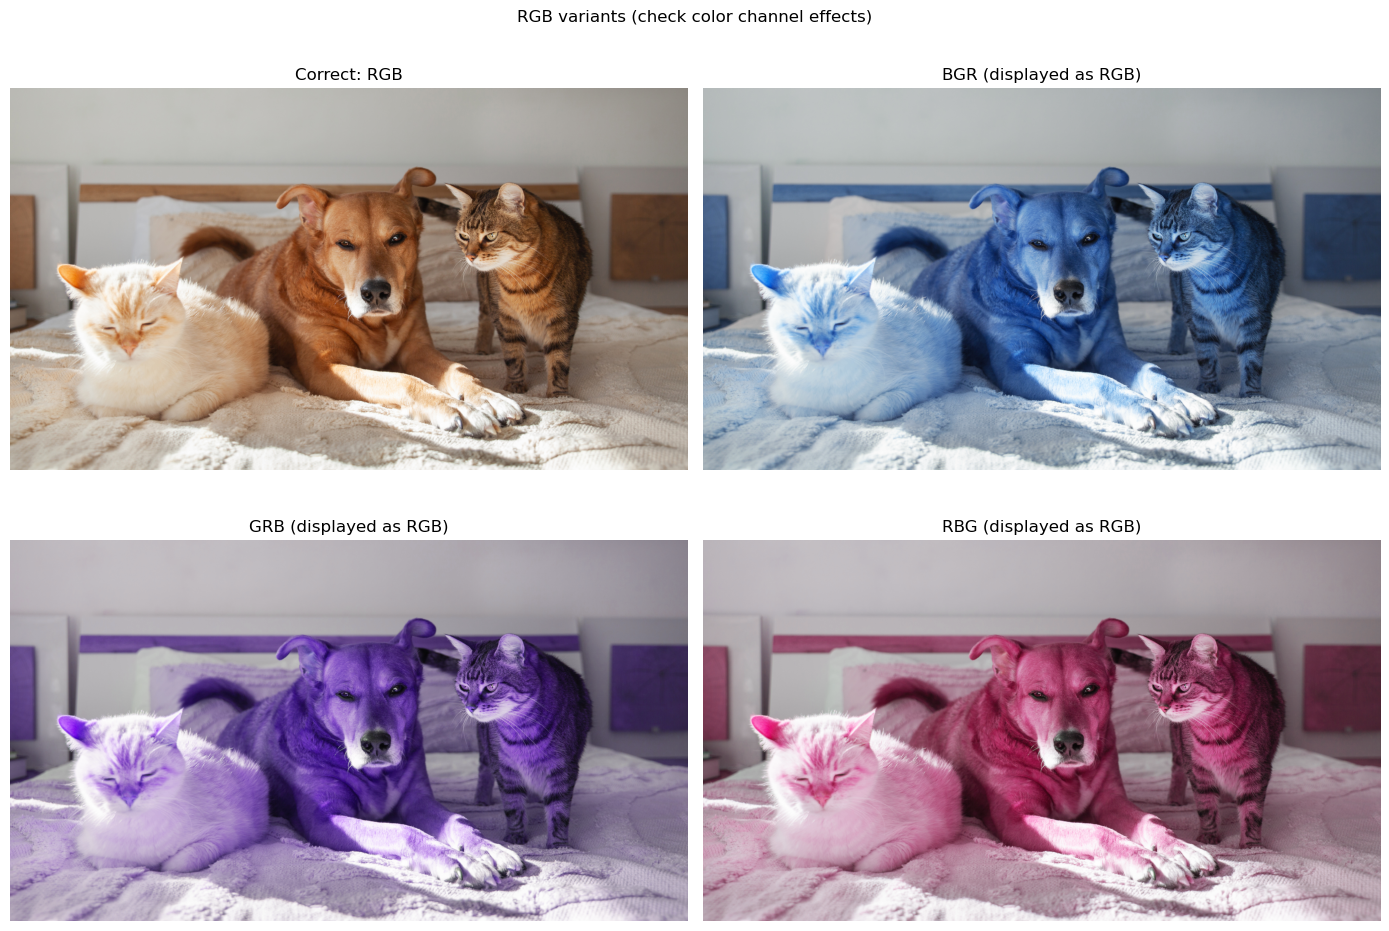

In [10]:
# Create color channel variants
img_rgb = img  # Correct order
img_bgr = img[:, :, [2, 1, 0]]  # B, G, R
img_grb = img[:, :, [1, 2, 0]]  # G, R, B
img_rbg = img[:, :, [0, 2, 1]]  # R, B, G

# Plot them in a 2x2 grid
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].imshow(img_rgb)
axes[0, 0].set_title("Correct: RGB")
axes[0, 0].axis('off')

axes[0, 1].imshow(img_bgr)
axes[0, 1].set_title("BGR (displayed as RGB)")
axes[0, 1].axis('off')

axes[1, 0].imshow(img_grb)
axes[1, 0].set_title("GRB (displayed as RGB)")
axes[1, 0].axis('off')

axes[1, 1].imshow(img_rbg)
axes[1, 1].set_title("RBG (displayed as RGB)")
axes[1, 1].axis('off')

plt.suptitle("RGB variants (check color channel effects)")
plt.tight_layout()
plt.show()

## Tensor Layout: HWC vs CHW

**HWC** (Height, Width, Channels):

- NumPy, PIL, TensorFlow default
- `(H, W, 3)`

**CHW** (Channels, Height, Width):

- **PyTorch default**
- `(3, H, W)`

**Batch format:**

- NCHW: `(batch, channels, height, width)` — PyTorch
- NHWC: `(batch, height, width, channels)` — TensorFlow

In [11]:
# Show conversion
print("NumPy (HWC):")
print(f"  Shape: {img.shape}")
print(f"  Access pixel (100, 150): {img[100, 150]}")

img_chw = np.transpose(img, (2, 0, 1))
print("\nPyTorch (CHW):")
print(f"  Shape: {img_chw.shape}")
print(f"  Access same pixel (channel, 100, 150): {img_chw[:, 100, 150]}")

print("\nConversion: np.transpose(img, (2, 0, 1))")

NumPy (HWC):
  Shape: (1299, 2309, 3)
  Access pixel (100, 150): [190 189 184]

PyTorch (CHW):
  Shape: (3, 1299, 2309)
  Access same pixel (channel, 100, 150): [190 189 184]

Conversion: np.transpose(img, (2, 0, 1))


## Transforms Pipeline

**A typical preprocessing pipeline:**

1. Resize
2. Crop
3. Flip (augmentation)
4. Convert to tensor
5. Normalize

Original shape (HWC): (1299, 2309, 3)
Transformed shape (CHW): torch.Size([3, 224, 224])
Transformed dtype: torch.float32
Transformed range: [0.027, 0.996]


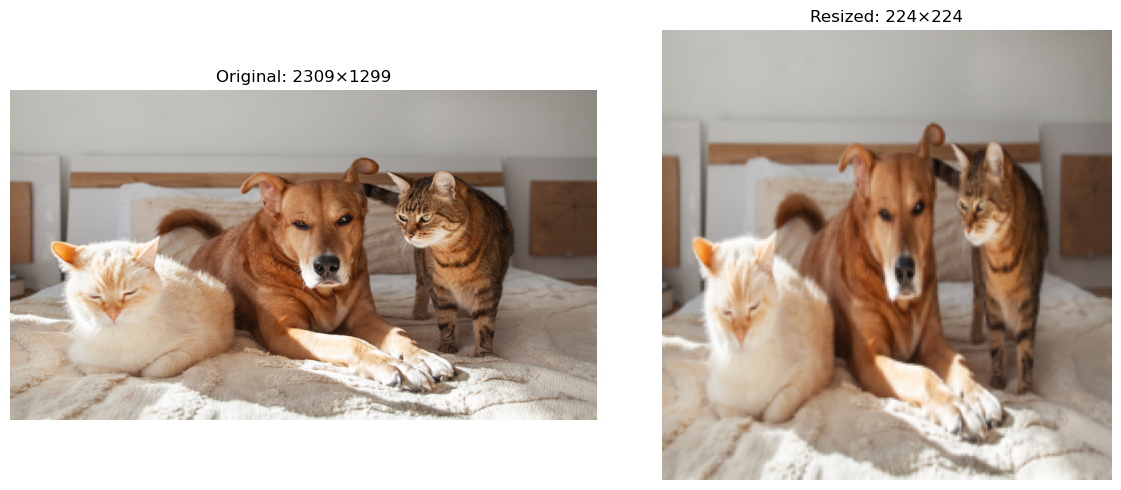

In [12]:
from torchvision import transforms

# Simple transform: resize and convert
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

img_transformed = transform(img_pil)

print(f"Original shape (HWC): {img.shape}")
print(f"Transformed shape (CHW): {img_transformed.shape}")
print(f"Transformed dtype: {img_transformed.dtype}")
print(f"Transformed range: [{img_transformed.min():.3f}, {img_transformed.max():.3f}]")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(img)
axes[0].set_title(f"Original: {img.shape[1]}×{img.shape[0]}")
axes[0].axis('off')

# Convert CHW back to HWC for display
img_display = img_transformed.permute(1, 2, 0).numpy()
axes[1].imshow(img_display)
axes[1].set_title(f"Resized: 224×224")
axes[1].axis('off')

plt.tight_layout()
plt.show()

# Sampling & Resolution

## Spatial Sampling (Images)

**Resolution = sampling density**

- Higher resolution = more detail, larger file, slower processing
- Downsampling = **discarding information**
- Interpolation ≠ magic detail recovery

**Trade-off:**
Detail vs computational cost

## Demo: Downsample the Real Image

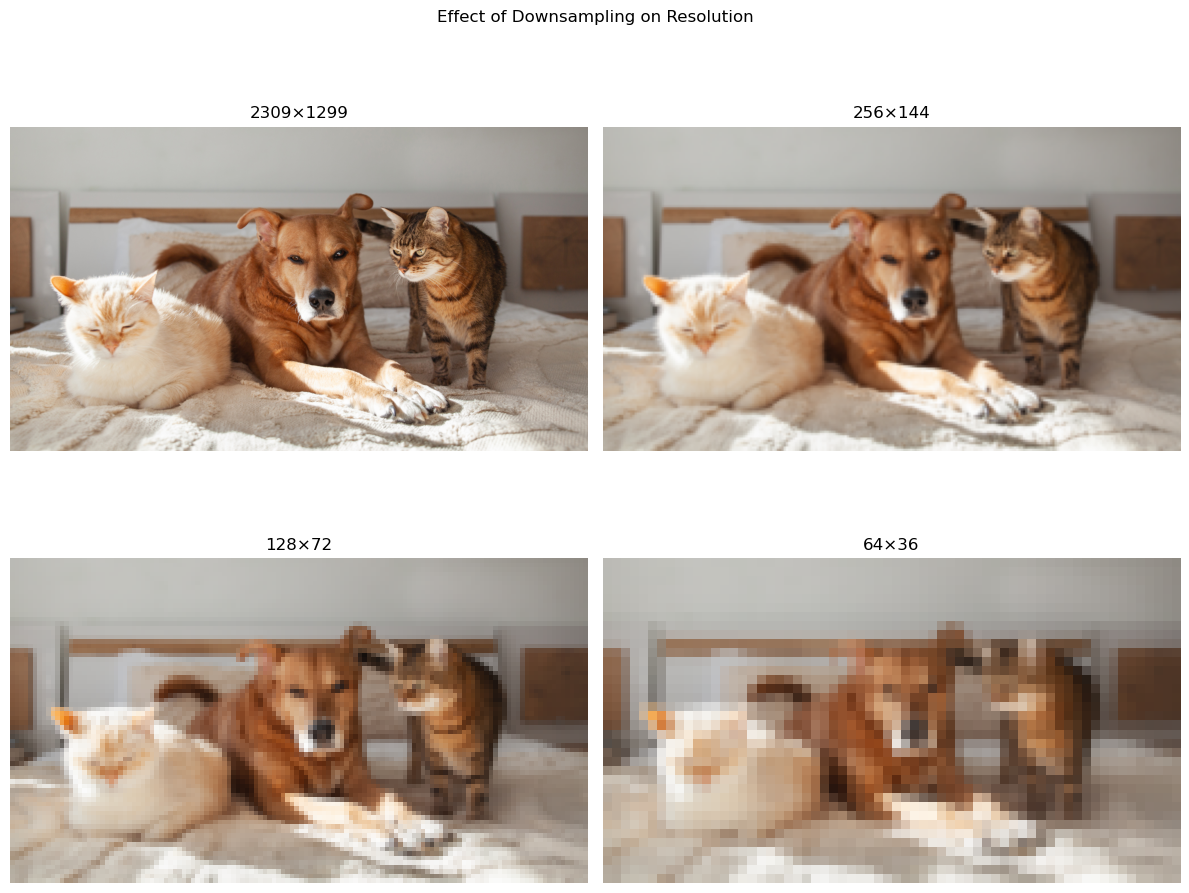


Original size: 2309×1299 (9.00 MB uncompressed)
Smallest size: 32×36 (6.9 KB uncompressed)


In [13]:
# Create downsampled versions
sizes = [img.shape[1], 256, 128, 64]  # Remove 128; keep original, 256, 64, 32
imgs_downsampled = []

for size in sizes:
    if size == img.shape[1]:
        imgs_downsampled.append(img)
    else:
        img_resized = img_pil.resize((size, int(size * img.shape[0] / img.shape[1])), Image.BILINEAR)
        imgs_downsampled.append(np.array(img_resized))

# Display as 2x2 grid
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()  # To make zip easier

for ax, img_down, size in zip(axes, imgs_downsampled, sizes):
    ax.imshow(img_down)
    ax.set_title(f"{img_down.shape[1]}×{img_down.shape[0]}")
    ax.axis('off')

plt.suptitle("Effect of Downsampling on Resolution")
plt.tight_layout()
plt.show() 

print(f"\nOriginal size: {img.shape[1]}×{img.shape[0]} ({img.size / 1e6:.2f} MB uncompressed)")
print(f"Smallest size: 32×{imgs_downsampled[-1].shape[0]} ({imgs_downsampled[-1].size / 1e3:.1f} KB uncompressed)")

## Demo: Upsample the Real Image

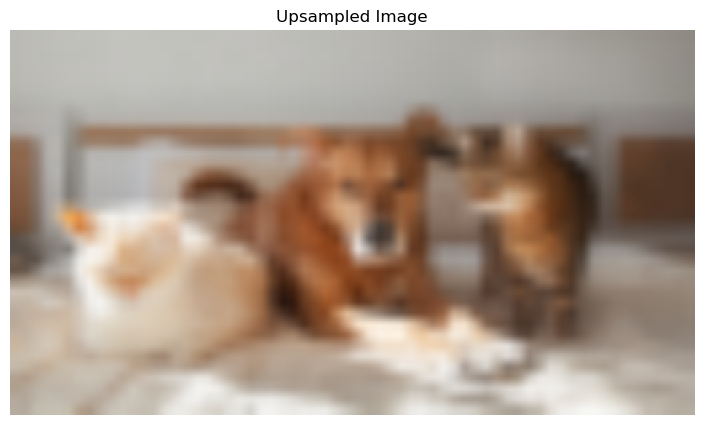

In [14]:
downsampled_img = imgs_downsampled[-1]
downsampled_img.shape

# Upsample the downsampled image to 256x144 using bilinear interpolation
upsampled_img = Image.fromarray(downsampled_img).resize((256, 144), Image.BILINEAR)

fig, ax = plt.subplots(figsize=(10, 5))
ax.imshow(upsampled_img)
ax.set_title("Upsampled Image")
ax.axis('off')
plt.show()


## Aliasing (Images)

**Aliasing:**

- High-frequency content masquerades as low-frequency
- Appears as moiré patterns, jagged edges, or "stair-stepping"

**Anti-aliasing:**

- Filtering before downsampling helps
- But still loses information

**Common in:**

- Thin lines / text
- Repeating patterns
- Fine textures

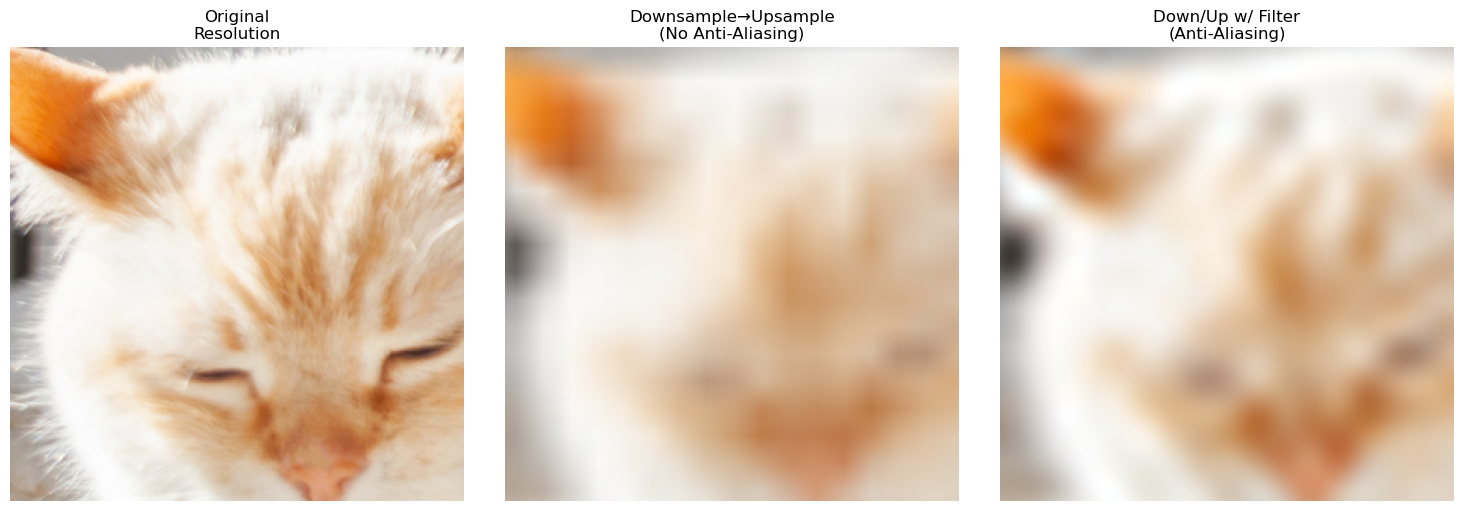

Key insight: Anti-aliasing filter REDUCES artifacts but CANNOT recover lost detail


In [15]:
# Show crops: original, downsampled (no filter), downsampled (with filter)
crop_y, crop_x = 600, 200
crop_size = 300

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Original crop
crop_orig = img[crop_y:crop_y+crop_size, crop_x:crop_x+crop_size]
axes[0].imshow(crop_orig)
axes[0].set_title("Original\nResolution")
axes[0].axis('off')

# Downsampled then upsampled (bilinear, no anti-aliasing)
img_down = img_pil.resize((128, int(128 * img.shape[0] / img.shape[1])), Image.BILINEAR)
img_up = img_down.resize((img.shape[1], img.shape[0]), Image.BILINEAR)
img_up_arr = np.array(img_up)
crop_down = img_up_arr[crop_y:crop_y+crop_size, crop_x:crop_x+crop_size]
axes[1].imshow(crop_down)
axes[1].set_title("Downsample→Upsample\n(No Anti-Aliasing)")
axes[1].axis('off')

# Downsampled with LANCZOS filter (anti-aliasing) then upsampled
img_down_filtered = img_pil.resize((128, int(128 * img.shape[0] / img.shape[1])), Image.LANCZOS)
img_up_filtered = img_down_filtered.resize((img.shape[1], img.shape[0]), Image.LANCZOS)
img_up_filtered_arr = np.array(img_up_filtered)
crop_down_filtered = img_up_filtered_arr[crop_y:crop_y+crop_size, crop_x:crop_x+crop_size]
axes[2].imshow(crop_down_filtered)
axes[2].set_title("Down/Up w/ Filter\n(Anti-Aliasing)")
axes[2].axis('off')


plt.tight_layout()
plt.show()

print("Key insight: Anti-aliasing filter REDUCES artifacts but CANNOT recover lost detail")

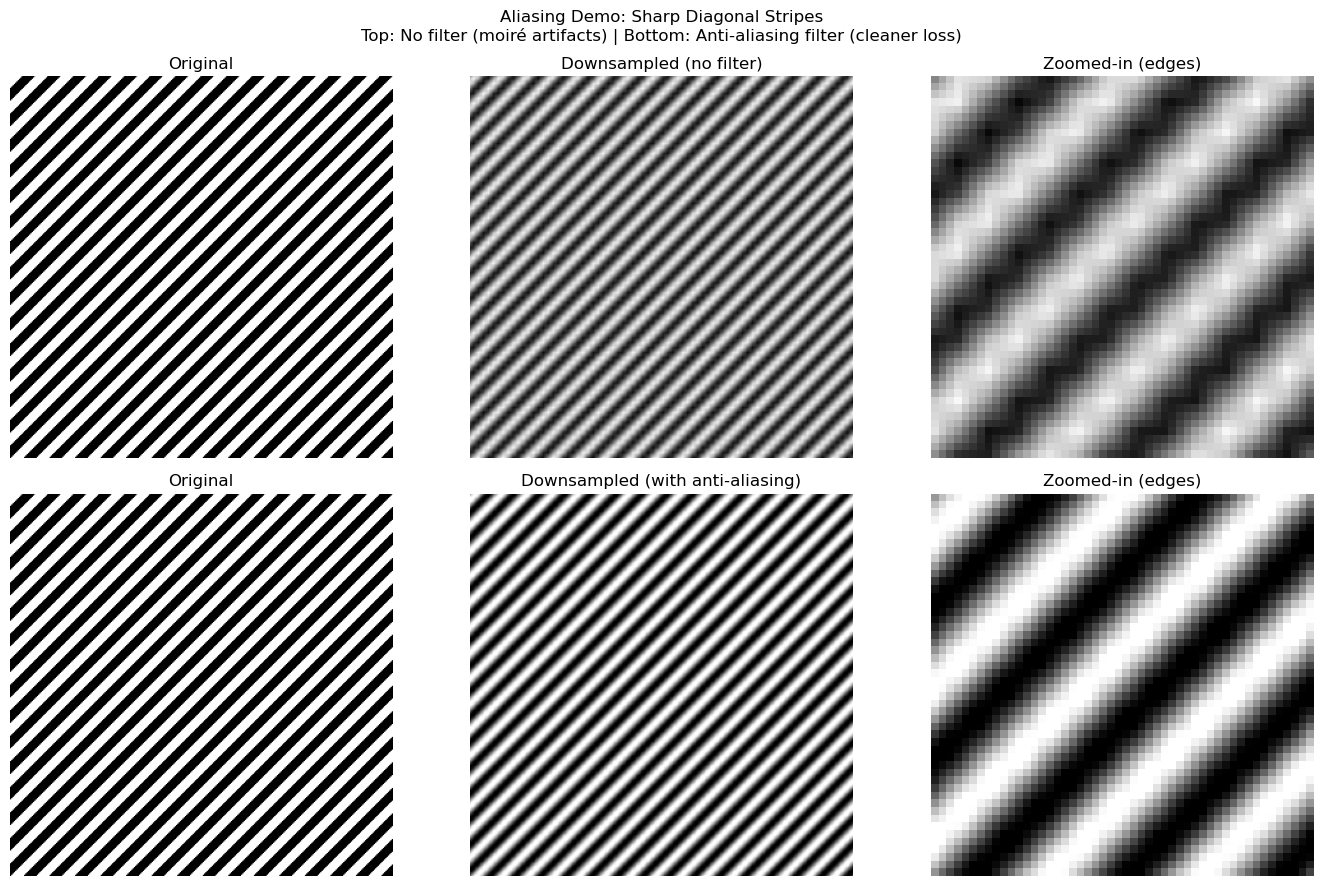

Notice: Top row shows harsh moiré patterns; bottom row is blurry but smoother


In [16]:
# Create synthetic image with sharp patterns to show aliasing more clearly
# Generate diagonal stripes pattern
size = 1000
stripe_img = np.zeros((size, size, 3), dtype=np.uint8)
for i in range(size):
    for j in range(size):
        if (i + j) % 20 < 10:  # Diagonal stripes
            stripe_img[i, j] = [255, 255, 255]  # White
        else:
            stripe_img[i, j] = [0, 0, 0]  # Black

stripe_pil = Image.fromarray(stripe_img)

# Extract a crop region for comparison
crop_y, crop_x = 300, 300
crop_size = 300

downsampled_size = 256

fig, axes = plt.subplots(2, 3, figsize=(14, 9))

# ===== ROW 1: WITHOUT anti-aliasing filter =====
# Original crop
crop_orig = stripe_img[crop_y:crop_y+crop_size, crop_x:crop_x+crop_size]
axes[0, 0].imshow(crop_orig)
axes[0, 0].set_title("Original")
axes[0, 0].axis('off')

# Downsample WITHOUT filtering (BILINEAR)
stripe_down = stripe_pil.resize((downsampled_size, downsampled_size), Image.BILINEAR)
stripe_up = stripe_down.resize((size, size), Image.BILINEAR)
stripe_up_arr = np.array(stripe_up)
crop_down = stripe_up_arr[crop_y:crop_y+crop_size, crop_x:crop_x+crop_size]
axes[0, 1].imshow(crop_down)
axes[0, 1].set_title("Downsampled (no filter)")
axes[0, 1].axis('off')

# Zoom in on the downsampled crop to show edges (no difference map)
zoom_crop = 50  # size of zoomed-in region
zoom_y, zoom_x = 50, 50  # relative to crop region
zoom_region = crop_down[zoom_y:zoom_y+zoom_crop, zoom_x:zoom_x+zoom_crop]
axes[0, 2].imshow(zoom_region)
axes[0, 2].set_title("Zoomed-in (edges)")
axes[0, 2].axis('off')

# ===== ROW 2: WITH anti-aliasing filter =====
# Original crop (same)
axes[1, 0].imshow(crop_orig)
axes[1, 0].set_title("Original")
axes[1, 0].axis('off')

# Downsample WITH filtering (LANCZOS)
stripe_down_filtered = stripe_pil.resize((downsampled_size, downsampled_size), Image.LANCZOS)
stripe_up_filtered = stripe_down_filtered.resize((size, size), Image.LANCZOS)
stripe_up_filtered_arr = np.array(stripe_up_filtered)
crop_down_filtered = stripe_up_filtered_arr[crop_y:crop_y+crop_size, crop_x:crop_x+crop_size]
axes[1, 1].imshow(crop_down_filtered)
axes[1, 1].set_title("Downsampled (with anti-aliasing)")
axes[1, 1].axis('off')

# Zoom in on the filtered crop to show edges (no difference map)
zoom_region = crop_down_filtered[100:100+zoom_crop, 100:100+zoom_crop]
axes[1, 2].imshow(zoom_region)
axes[1, 2].set_title("Zoomed-in (edges)")
axes[1, 2].axis('off')

plt.suptitle("Aliasing Demo: Sharp Diagonal Stripes\nTop: No filter (moiré artifacts) | Bottom: Anti-aliasing filter (cleaner loss)")
plt.tight_layout()
plt.show()

print("Notice: Top row shows harsh moiré patterns; bottom row is blurry but smoother")

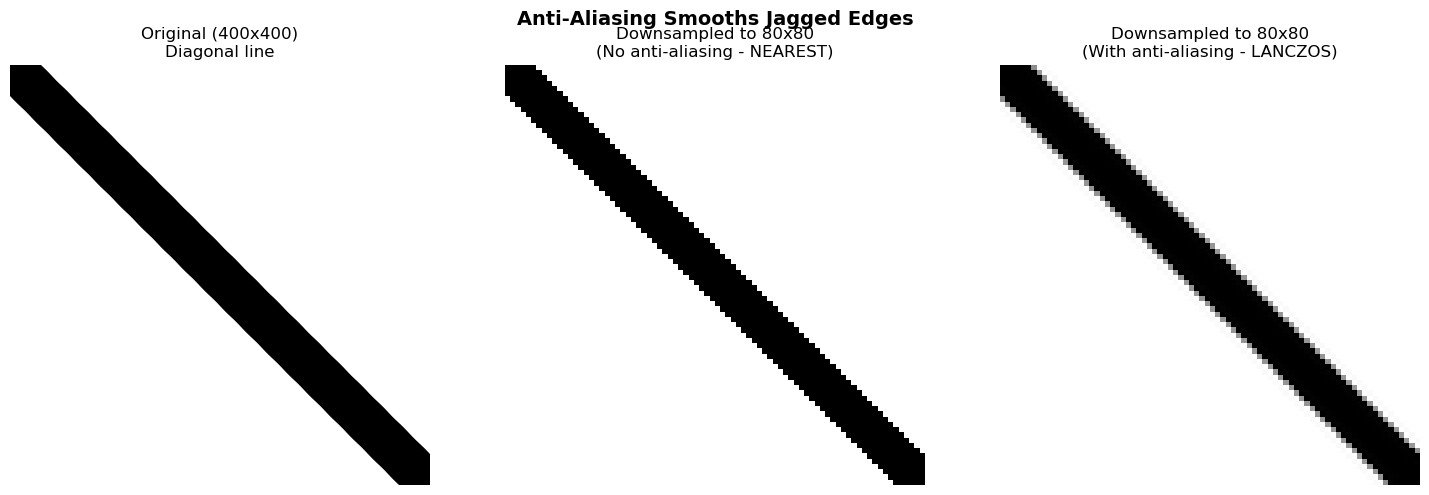

Key insight: Anti-aliasing adds intermediate gray pixels to smooth diagonal edges


In [17]:
# Create a diagonal line to show jagged edges vs anti-aliasing
size = 400
line_img = np.ones((size, size, 3), dtype=np.uint8) * 255  # White background

# Draw a thick diagonal line from top-left to bottom-right
thickness = 30
for i in range(size):
    y = i
    x = i
    # Draw thick line by filling a rectangle around the diagonal
    y_start = max(0, y - thickness // 2)
    y_end = min(size, y + thickness // 2)
    x_start = max(0, x - thickness // 2)
    x_end = min(size, x + thickness // 2)
    line_img[y_start:y_end, x_start:x_end] = [0, 0, 0]  # Black

line_pil = Image.fromarray(line_img)

# Downsample aggressively to make artifacts visible
target_size = 80

# Without anti-aliasing (NEAREST - preserves jagged edges)
line_down_no_aa = line_pil.resize((target_size, target_size), Image.NEAREST)

# With anti-aliasing (LANCZOS - smooths edges)
line_down_with_aa = line_pil.resize((target_size, target_size), Image.LANCZOS)

# Plot comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(line_img)
axes[0].set_title("Original (400x400)\nDiagonal line")
axes[0].axis('off')

axes[1].imshow(line_down_no_aa)
axes[1].set_title(f"Downsampled to {target_size}x{target_size}\n(No anti-aliasing - NEAREST)")
axes[1].axis('off')

axes[2].imshow(line_down_with_aa)
axes[2].set_title(f"Downsampled to {target_size}x{target_size}\n(With anti-aliasing - LANCZOS)")
axes[2].axis('off')

plt.suptitle("Anti-Aliasing Smooths Jagged Edges", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Key insight: Anti-aliasing adds intermediate gray pixels to smooth diagonal edges")

## Temporal Sampling (Audio)

**Sample rate (Hz):**

- Samples per second
- CD quality: 44.1 kHz
- Speech: often 16 kHz

**Nyquist theorem:**

- Need ≥ 2× highest frequency to avoid aliasing
- Example: human hearing ≈ 20 Hz–20 kHz → sample at ≥ 40 kHz

## Demo: Sample-Rate Effects

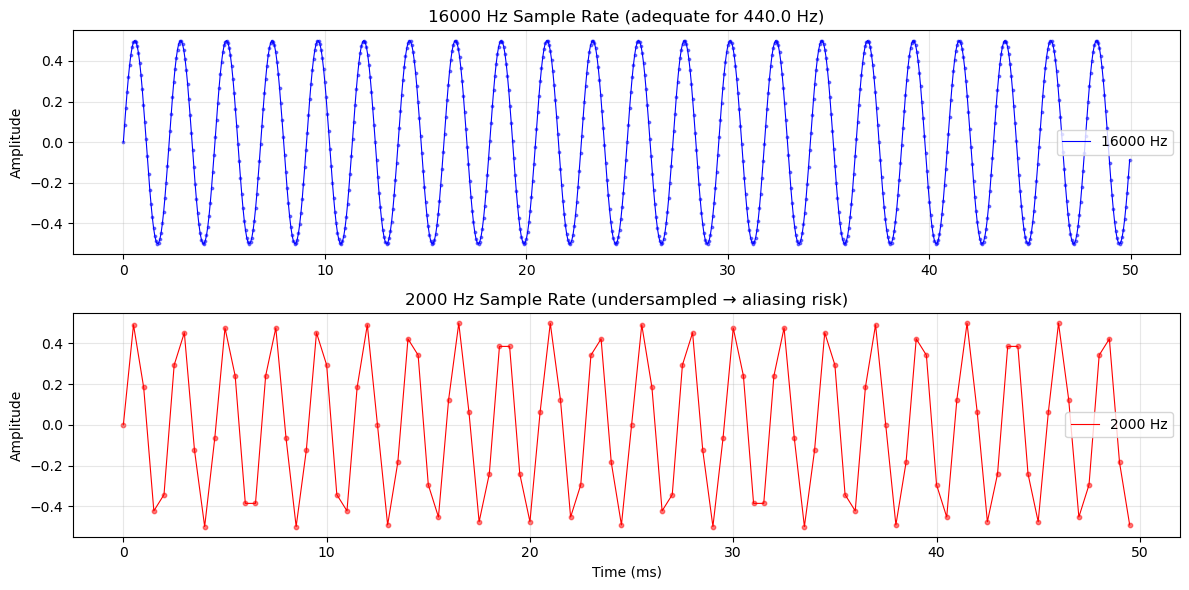


Nyquist frequency at 2000 Hz: 1000.0 Hz
Our signal frequency: 440.0 Hz
Result: 440.0 Hz > 1000.0 Hz → undersampled!


In [18]:
# Generate sine waves at different sample rates
duration = 0.05  # 50ms for visualization
frequency = 440.0

# High sample rate
sr_high = 16000
t_high = np.linspace(0, duration, int(sr_high * duration), endpoint=False)
audio_high = 0.5 * np.sin(2 * np.pi * frequency * t_high)

# Low sample rate (undersampled, won't many browser will not be able to play)
sr_low = 2000
t_low = np.linspace(0, duration, int(sr_low * duration), endpoint=False)
audio_low = 0.5 * np.sin(2 * np.pi * frequency * t_low)

# Plot
fig, axes = plt.subplots(2, 1, figsize=(12, 6))

axes[0].plot(t_high * 1000, audio_high, 'b-', linewidth=0.8, label=f'{sr_high} Hz')
axes[0].scatter(t_high * 1000, audio_high, s=3, c='blue', alpha=0.5)
axes[0].set_ylabel("Amplitude")
axes[0].set_title(f"{sr_high} Hz Sample Rate (adequate for {frequency} Hz)")
axes[0].grid(alpha=0.3)
axes[0].legend()

axes[1].plot(t_low * 1000, audio_low, 'r-', linewidth=0.8, label=f'{sr_low} Hz')
axes[1].scatter(t_low * 1000, audio_low, s=10, c='red', alpha=0.5)
axes[1].set_xlabel("Time (ms)")
axes[1].set_ylabel("Amplitude")
axes[1].set_title(f"{sr_low} Hz Sample Rate (undersampled → aliasing risk)")
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\nNyquist frequency at {sr_low} Hz: {sr_low / 2} Hz")
print(f"Our signal frequency: {frequency} Hz")
print(f"Result: {frequency} Hz > {sr_low / 2} Hz → undersampled!")



# Quantization & Dynamic Range

## Quantization

**Quantization:**
Mapping continuous values → discrete levels

**Image quantization:**

- 8-bit: 256 levels per channel (0–255)
- 16-bit: 65,536 levels (HDR)

**Model inputs:**

- Typically float: 0–1 or normalized
- Conversion: `img.astype(float) / 255.0`

## Demo: Quantize the Real Image

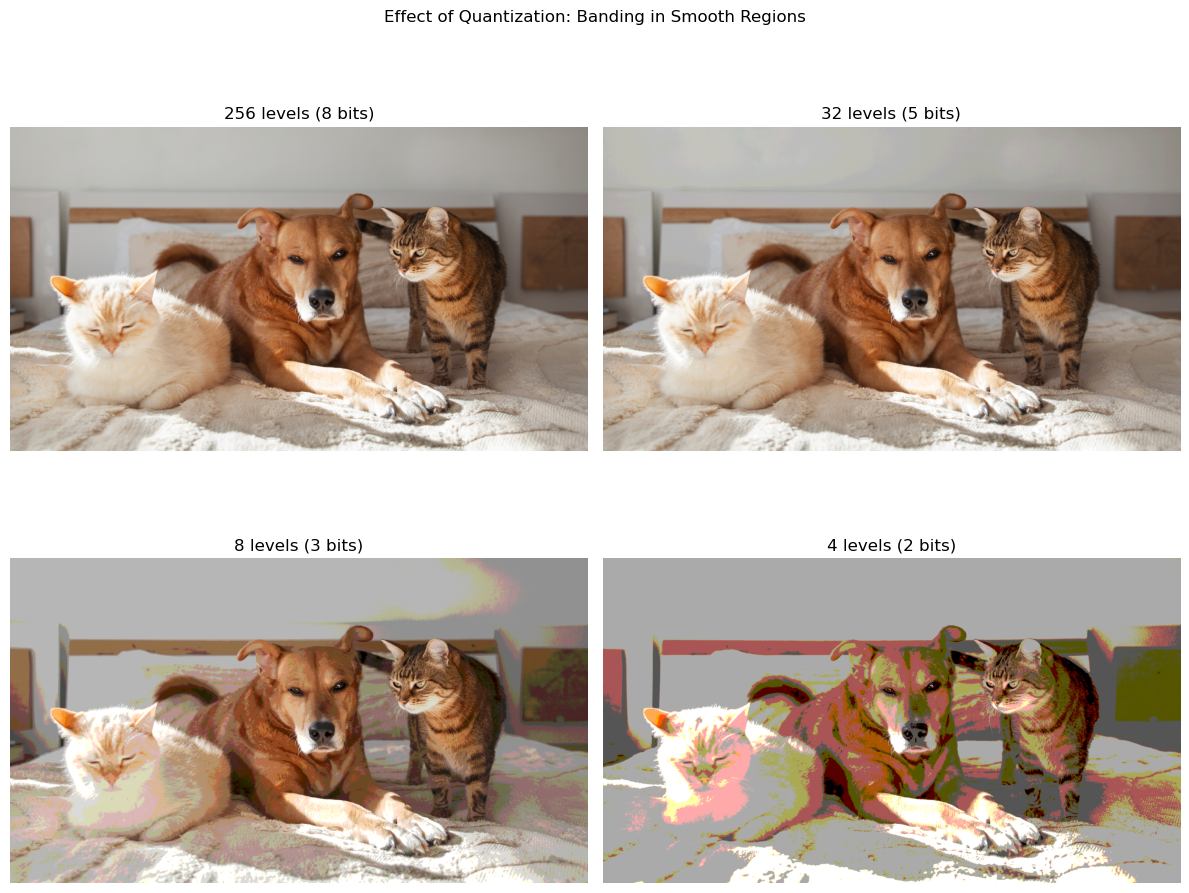

In [19]:
def quantize(img, levels):
    """Reduce to n levels"""
    scale = 255 / (levels - 1)
    quantized = np.round(img / scale) * scale
    return np.clip(quantized, 0, 255).astype(np.uint8)

levels = [256, 32, 8, 4]
imgs_quantized = [quantize(img, l) for l in levels]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for ax, img_q, l in zip(axes, imgs_quantized, levels):
    ax.imshow(img_q)
    ax.set_title(f"{l} levels ({int(np.log2(l))} bits)")
    ax.axis('off')

plt.suptitle("Effect of Quantization: Banding in Smooth Regions")
plt.tight_layout()
plt.show()

## Dynamic Range

**Dynamic range:**
Ratio between largest and smallest representable values

**Image issues:**

- **Saturation** (too bright): detail lost in highlights
- **Crush** (too dark): detail lost in shadows

**Normalization:**

- Helps training stability
- Common: subtract mean, divide by std
- ImageNet stats: `mean=[0.485, 0.456, 0.406]`, `std=[0.229, 0.224, 0.225]`

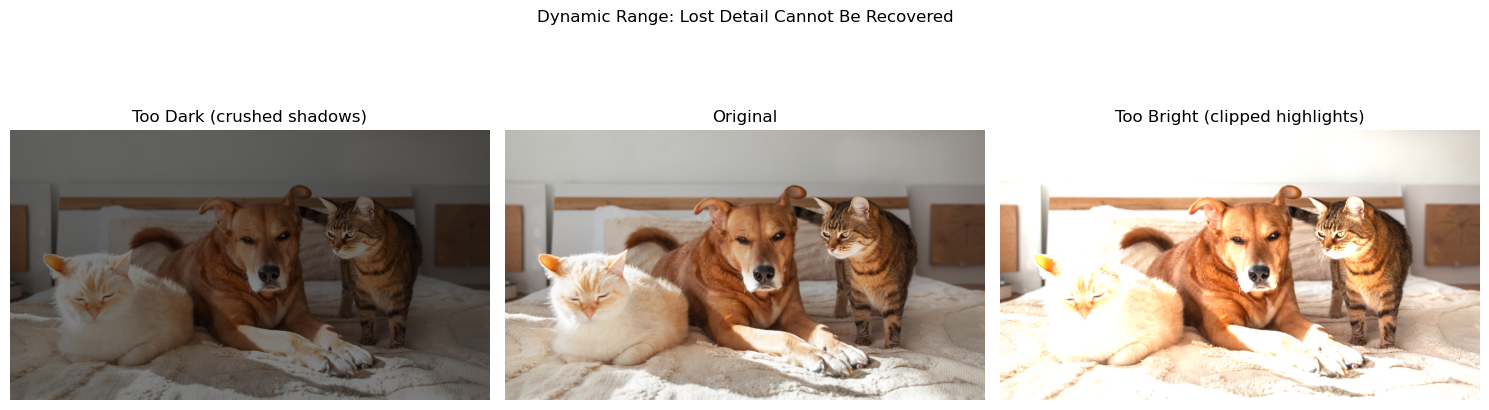

In [20]:
# Artificially brighten/darken and clip
img_bright = np.clip(img * 1.5, 0, 255).astype(np.uint8)
img_dark = np.clip(img * 0.5, 0, 255).astype(np.uint8)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(img_dark)
axes[0].set_title("Too Dark (crushed shadows)")
axes[0].axis('off')

axes[1].imshow(img)
axes[1].set_title("Original")
axes[1].axis('off')

axes[2].imshow(img_bright)
axes[2].set_title("Too Bright (clipped highlights)")
axes[2].axis('off')

plt.suptitle("Dynamic Range: Lost Detail Cannot Be Recovered")
plt.tight_layout()
plt.show()

# Datasets, Splits, and Leakage

## Dataset Structures in the Wild

**Common formats:**

1. **Folder-per-class:**
```
data/
  train/
    class1/
    class2/
  val/
    class1/
    class2/
```

2. **Flat + CSV:**
```
images/
  img001.jpg
  img002.jpg
labels.csv
```

3. **COCO-style annotations:**
- JSON with bounding boxes, segments, keypoints

## Data Leakage 

**Data leakage:**
When information from test/validation "leaks" into training

### CV-Specific Leakage Patterns:

1. **Near-duplicate leakage:**
   - Multiple crops/augmentations of same image across splits
   - Example: train on crop A, test on crop B from same image

2. **Group leakage:**
   - Multiple frames from same video
   - Multiple patches from same patient scan
   - Multiple views of same scene

3. **Patch/region leakage:**
   - Overlapping patches from same image
   - Example: 128×128 patches with 64-pixel stride

4. **Preprocessing leakage:**
   - Computing normalization stats on entire dataset before split

## Group-Aware Splitting

**Key principle:**
Split by **scene/video/patient**, not by **frame/patch**

**Example:**

- **Not Ideal**: randomly split 10,000 video frames
- **Better**: split 100 videos, then use their frames

**Why it matters:**

- Frames from same video are highly correlated
- Model can "memorize" specific scenes
- Test performance will be overoptimistic

## Mini-Case: Preprocessing Leakage (Learned Preprocessing)

The leak that actually bites in practice is when preprocessing **learns parameters** from the data.

**Wrong (leaky): fit preprocessing on ALL data**

```python
# Bad: preprocessing learns from train+test together
X_all = concat(X_train, X_test)

# Examples of learned preprocessing:
mu, sigma = channel_mean_std(X_all)     # normalization stats
W = pca_fit(X_all, k=64)               # PCA basis / whitening

X_train_p = apply_preprocessing(X_train, mu, sigma, W)
X_test_p  = apply_preprocessing(X_test,  mu, sigma, W)
```

**Right: split first, then fit on TRAIN only**

```python
# Good: split first
X_train, X_test = split(X)

# Fit preprocessing ONLY on training data
mu, sigma = channel_mean_std(X_train)
W = pca_fit(X_train, k=64)

X_train_p = apply_preprocessing(X_train, mu, sigma, W)
X_test_p  = apply_preprocessing(X_test,  mu, sigma, W)  # apply train-fitted params
```

**Why it matters:** PCA/whitening/feature selection can "peek" at structure in the test set and inflate results.

**Key rule:** If a step **fits/learns** anything (stats, basis, thresholds), fit it on **training only**, then apply to val/test.

# PyTorch Ecosystem

## PyTorch + torchvision + torchaudio

**What you should remember:**

**Core abstractions:**

- `Dataset`: defines `__len__()` and `__getitem__(idx)`
- `DataLoader`: batching, shuffling, parallel loading
- `transforms`: preprocessing and augmentation

**torchvision:**

- Pretrained models (ResNet, ViT, etc.)
- Built-in datasets (CIFAR-10, ImageNet, COCO)
- Transform utilities

**torchaudio:**

- Audio I/O
- Spectrograms and transforms

## Quiz 1 Study Guide

**Core topics you should know for the quiz:**

### 1. Tensor Shapes & Indexing
- **NumPy/PIL convention**: `(H, W, C)` - height, width, channels
- **PyTorch convention**: `(C, H, W)` - channels, height, width
- **Batch dimension**: `(N, C, H, W)` where N = batch size
- **Array indexing**: `img[row, col]` - row first, column second
- **Example**: MNIST batch with `transforms.ToTensor()` has shape `(64, 1, 28, 28)`

### 2. Coordinate Systems & Plotting
- **Image origin**: Top-left corner (0, 0)
- **Array indexing vs plotting**:
  - Array: `img[row, col]`
  - Matplotlib: `plot(x=col, y=row)` - column first!
- Know why these are different and when each is used

### 3. Quantization & Bit Depth
- **Quantization** = mapping continuous values to discrete levels
- **8-bit image**: 2^8 = 256 unique values per channel (0-255)
- **16-bit image**: 2^16 = 65,536 unique values
- **Lower bit depth** = fewer levels = posterization artifacts

### 4. File Formats & Compression
- **PNG**: Lossless compression, preserves exact pixel values
- **JPEG**: Lossy compression, smaller files but changes pixel values
- **Best practice**: Use lossless (PNG/WAV) during analysis, lossy for final sharing
- **Why?** Avoid accumulating artifacts from repeated saves

### 5. Sampling & Aliasing
- **Spatial sampling** (images): Resolution in pixels (H x W)
- **Temporal sampling** (audio): Sample rate in Hz (samples per second)
- **Anti-aliasing filter**: Reduces artifacts when downsampling
  - Does NOT recover lost detail - detail is gone forever
  - Just makes the blur cleaner (no moire patterns)

### 6. Audio & Nyquist Frequency
- **Nyquist frequency** = sample_rate / 2
- **Rule**: To capture a signal, sample rate must be > 2x the highest frequency
- **Example**: 16 kHz sample rate can capture up to 8 kHz frequencies
- **Calculation**: samples = duration (seconds) x sample_rate (Hz)

### 7. Channel Conventions
- **RGB order**: Most libraries (PIL, torchvision, matplotlib)
- **BGR order**: OpenCV uses this (watch for bugs!)
- **In CHW tensor**: Red = index 0, Green = 1, Blue = 2

### 8. Data Leakage
- **Definition**: Test/validation information leaking into training
- **Common examples**:
  - Computing normalization stats on train+test (correct: train only)
  - Same subject/group in both train and validation
  - Using test set to tune hyperparameters
  - Fitting preprocessing (PCA, scaling) on all data instead of train only
- **NOT leakage**: Shuffling training set, computing stats on train only

### 9. PyTorch Data Pipeline
- **Dataset**: Stores samples, implements `__len__` and `__getitem__`
- **DataLoader**: Batches data, handles shuffling and parallel loading
- **Transforms**: Applied per-sample (e.g., `ToTensor()`, normalization)
- **Key**: Fit transform stats on training data only

### 10. Potential quiz concepts
- Convert between time (ms) and sample indices for audio
- Recognize correct tensor shapes for different conventions
- Identify data leakage scenarios
- Calculate unique values from bit depth
- Understand why anti-aliasing doesn't recover detail

## Wrap-Up

**Three key takeaways:**

1. **Everything is a tensor** — shape thinking is a survival skill
2. **Conventions matter** — coordinates, channels, layouts cause silent bugs
3. **Leakage breaks results** — split carefully (especially for video/medical)

**Next week:**

- Classical computer vision
- Filtering and convolution
- Edge detection
- Morphological operations